# Create submission plots:

In [2]:
import sys
from pathlib import Path

# Adjust this path to where config.py is located
code_dir = Path("/cluster/work/boeva/lrabuzin/deepcast/src")  # or something relative like ../code
sys.path.append(str(code_dir))

## Pathogenic phenotypes

In [3]:
import pandas as pd
from config import DATA_DIR


phenotype_identifiers = pd.read_csv(DATA_DIR / 'phenotype_identifier.csv', usecols = ["phen_id", "trait_type", "phenocode"])
phenotype_identifiers = phenotype_identifiers[phenotype_identifiers["trait_type"]=='icd10']
phenotype_identifiers["phenocode"] = phenotype_identifiers["phenocode"].str[0]
phenotype_identifiers = phenotype_identifiers.set_index('phen_id')["phenocode"].to_dict()

In [4]:
from config import DEEPCAST_DIR

phen_ids_path = DEEPCAST_DIR / 'icd10_trait_phen_ids.txt'

with open(phen_ids_path, "r", encoding="utf-8") as f:
    phen_ids = [int(line.strip()) for line in f]

result_folders = ['phen' + str(id) for id in phen_ids]

### Gather sFDR data

In [5]:
import pandas as pd
from config import DEEPCAST_DIR, RESULTS_DIR
from input_output import retrieve_n_controls

cadd_folder_path = RESULTS_DIR / 'cadd_sfdr' / 'run_7676709'
deepcast_folder_path = RESULTS_DIR / 'deepcast_sfdr' / 'run_7662700'

n_cases = []
p_cases = []
newly_disc_cadd = []
newly_disc_deepcast = []
recov_cadd = []
recov_deepcast = []
datapoints_sfdr = 0
icd_category = []
missing_phens_sfdr = []
baseline_loci = []

for phen_id, folder in zip(phen_ids, result_folders):
    cadd_dir = cadd_folder_path / folder
    deepcast_dir = deepcast_folder_path / folder
    if cadd_dir.exists():
        if deepcast_dir.exists():
            metadata_cadd = pd.read_csv(cadd_dir / "metadata.csv")
            metadata_deepcast = pd.read_csv(deepcast_dir / "metadata.csv")
            n_cases.append(metadata_cadd['n_cases'][0])
            newly_disc_cadd.append(metadata_cadd['num_newly_discovered_loci'][0])
            newly_disc_deepcast.append(metadata_deepcast['num_newly_discovered_loci'][0])
            recov_cadd.append(metadata_cadd['percentage_loci_recovered'][0])
            recov_deepcast.append(metadata_deepcast['percentage_loci_recovered'][0])
            baseline_loci.append(metadata_deepcast['num_loci_baseline'][0])
            icd_category.append(phenotype_identifiers[phen_id])
            p_cases.append(metadata_cadd['n_cases'][0]/(retrieve_n_controls(phen_id)+metadata_cadd['n_cases'][0]))
            datapoints_sfdr+=1
        else:
            print(f'For {folder}: no deepcast results were found at {deepcast_dir}')
            missing_phens_sfdr.append(folder)
    else:
        print(f'For {folder}: no cadd results were found at {cadd_dir}')
        missing_phens_sfdr.append(folder)

sfdr_results = pd.DataFrame({'n_cases':n_cases,
                             'p_cases':p_cases,
                                'newly_disc_cadd':newly_disc_cadd,
                                'newly_disc_deepcast':newly_disc_deepcast,
                                'recov_cadd':recov_cadd,
                                'recov_deepcast':recov_deepcast,
                                'icd_category':icd_category,
                                'baseline_loci':baseline_loci})

### Gather FWER data

In [6]:
import pandas as pd
from config import RESULTS_DIR
from input_output import retrieve_n_controls

findor_folder_path = RESULTS_DIR / 'benchmark_findor' / 'run_7535279'
deepcast_folder_path = RESULTS_DIR / 'run_7535278'

n_cases = []
p_cases = []
newly_disc_findor = []
newly_disc_deepcast = []
recov_findor = []
recov_deepcast = []
datapoints_fwer = 0
icd_category = []
missing_phens_fwer = []
baseline_loci = []


for phen_id, folder in zip(phen_ids, result_folders):
    findor_dir = findor_folder_path / folder
    deepcast_dir = deepcast_folder_path / folder
    if findor_dir.exists():
        if deepcast_dir.exists():
            metadata_findor = pd.read_csv(findor_dir / "metadata.csv")
            metadata_deepcast = pd.read_csv(deepcast_dir / "metadata.csv")
            n_cases.append(metadata_findor['n_cases'][0])
            newly_disc_findor.append(metadata_findor['num_newly_discovered_loci'][0])
            newly_disc_deepcast.append(metadata_deepcast['num_newly_discovered_loci'][0])
            recov_findor.append(metadata_findor['percentage_loci_recovered'][0])
            recov_deepcast.append(metadata_deepcast['percentage_loci_recovered'][0])
            baseline_loci.append(metadata_deepcast['num_loci_baseline'][0])
            icd_category.append(phenotype_identifiers[phen_id])
            p_cases.append(metadata_cadd['n_cases'][0]/(retrieve_n_controls(phen_id)+metadata_cadd['n_cases'][0]))
            datapoints_fwer+=1
        else:
            print(f'For {folder}: no deepcast results were found at {deepcast_dir}')
            missing_phens_fwer.append(folder)
    else:
        print(f'For {folder}: no findor results were found at {findor_dir}')
        missing_phens_fwer.append(folder)

fwer_results = pd.DataFrame({'n_cases':n_cases,
                             'p_cases':p_cases,
                                'newly_disc_findor':newly_disc_findor,
                                'newly_disc_deepcast':newly_disc_deepcast,
                                'recov_findor':recov_findor,
                                'recov_deepcast':recov_deepcast,
                                'icd_category':icd_category,
                                'baseline_loci':baseline_loci})

For phen4583: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen4583
For phen5099: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5099
For phen5101: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5101
For phen5104: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5104
For phen5106: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5106
For phen5109: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5109
For phen5110: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/results/benchmark_findor/run_7535279/phen5110
For phen5111: no findor results were found at /cluster/work/boeva/lrabuzin/deepcast/result

### Data visualization

We want a histogram of the number of significant SNPs for the conventional GWAS (we need to use the sfdr DataFrame since the fwer one doesn't contain all phenotypes)

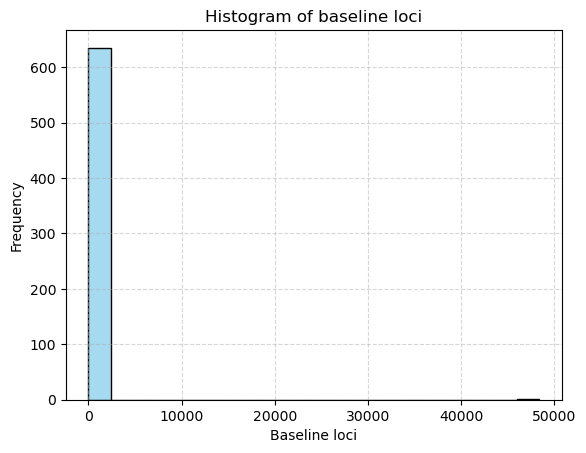

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=sfdr_results, x='baseline_loci', bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Baseline loci')
plt.ylabel('Frequency')
plt.title('Histogram of baseline loci')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

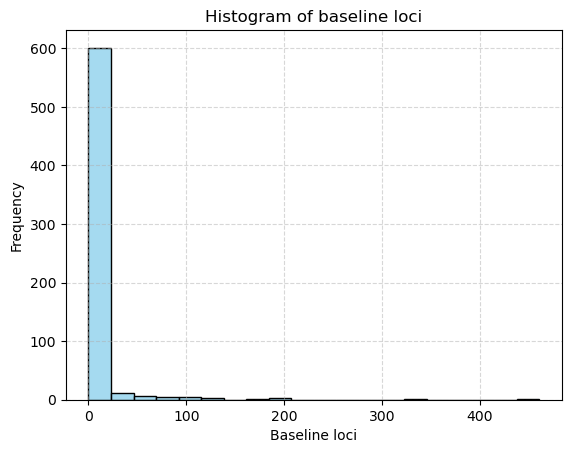

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=sfdr_results[sfdr_results['baseline_loci']<4000], x='baseline_loci', bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Baseline loci')
plt.ylabel('Frequency')
plt.title('Histogram of baseline loci')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [8]:
len(sfdr_results[sfdr_results['baseline_loci']==0])

430

In [9]:
sfdr_results[sfdr_results['baseline_loci']>300]

,n_cases,newly_disc_cadd,newly_disc_deepcast,recov_cadd,recov_deepcast,icd_category,baseline_loci
95,17592.0,201,215,1.0,1.0,E,334
394,2498.0,105,110,1.0,1.0,K,461
540,1091.0,48887,48131,1.0,1.0,O,48390


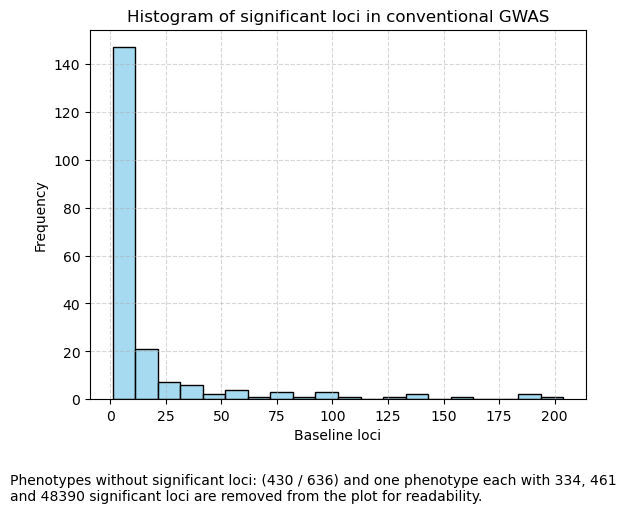

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=sfdr_results[(sfdr_results['baseline_loci']<300) & (sfdr_results['baseline_loci']>0)], x='baseline_loci', bins=20, edgecolor='black', color='skyblue')
plt.xlabel('Baseline loci')
plt.ylabel('Frequency')
plt.title('Histogram of significant loci in conventional GWAS')
plt.grid(True, linestyle='--', alpha=0.5)
plt.figtext(0, -0.1, f'Phenotypes without significant loci: (430 / 636) and one phenotype each with 334, 461\nand 48390 significant loci are removed from the plot for readability.')
plt.savefig("plots/significant_snp_histogram.pdf", format="pdf", bbox_inches="tight")
plt.show()

### FWER plots

We want a scatterplot of recovered loci by deepcast and findor for each phenotype.

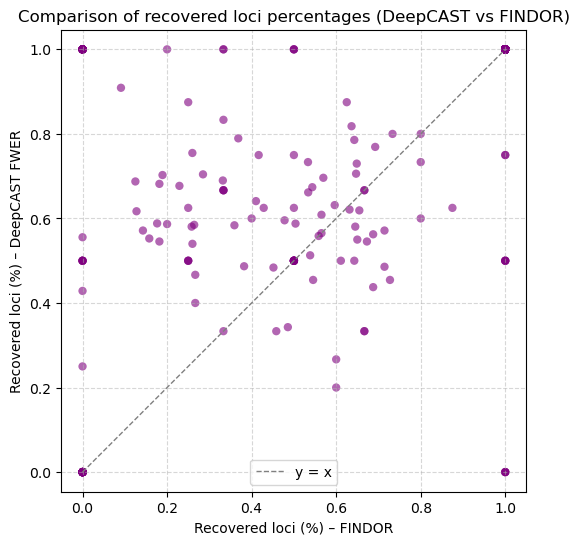

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatterplot
sns.scatterplot(
    data=fwer_results,
    x='recov_findor',
    y='recov_deepcast',
    color='purple',
    alpha=0.6,
    edgecolor='none'
)

# 45° equality line (y = x)
min_val = min(fwer_results['recov_findor'].min(), fwer_results['recov_deepcast'].min())
max_val = max(fwer_results['recov_findor'].max(), fwer_results['recov_deepcast'].max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', linewidth=1, label='y = x')

plt.xlabel("Recovered loci (%) – FINDOR")
plt.ylabel("Recovered loci (%) – DeepCAST FWER")
plt.title("Comparison of recovered loci percentages (DeepCAST vs FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.axis('equal')
plt.savefig("plots/fwer_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()


We want a scatterplot of newly discovered loci by deepcast and findor for each phenotype:

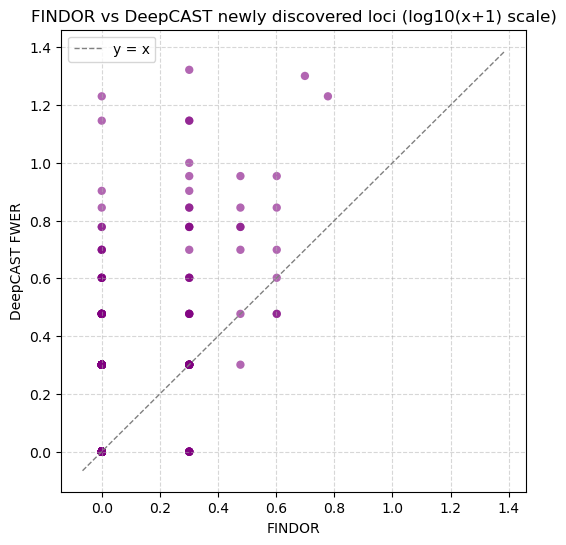

In [ ]:
plt.figure(figsize=(6,6))

sns.scatterplot(data=fwer_results, x=np.log10(fwer_results['newly_disc_findor']+1),
                          y=np.log10(fwer_results['newly_disc_deepcast']+1),
                          alpha=0.6, color='purple', edgecolor='none')
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, '--', color='gray', linewidth=1, label='y = x')
plt.xlabel("FINDOR"); plt.ylabel("DeepCAST FWER")
plt.title("FINDOR vs DeepCAST newly discovered loci (log10(x+1) scale)"); plt.grid(True, which="both", linestyle="--", alpha=0.5); plt.legend();
plt.savefig("plots/fwer_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

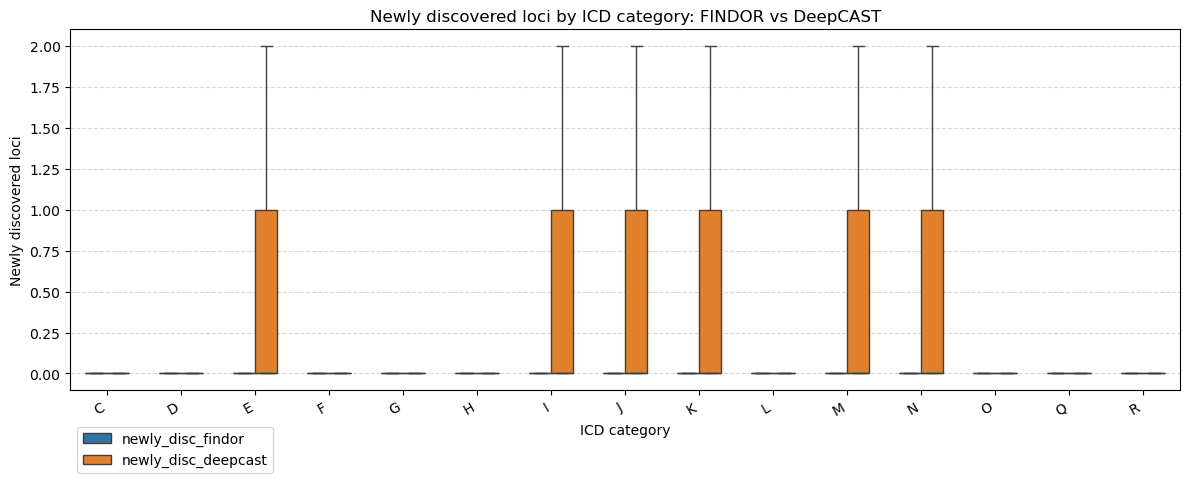

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Long format: one row per (icd_category, method, value)
long = (
    fwer_results[['icd_category', 'newly_disc_findor', 'newly_disc_deepcast']]
    .melt(id_vars='icd_category',
          value_vars=['newly_disc_findor', 'newly_disc_deepcast'],
          var_name='method', value_name='newly_disc')
    .dropna()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=long, x='icd_category', y='newly_disc', hue='method',
    dodge=True, width=0.6, showfliers=False  # set showfliers=True if you want outliers
)

# Optional: overlay points for visibility (comment out if not needed)
# sns.stripplot(data=long, x='icd_category', y='recovered', hue='method',
#               dodge=True, alpha=0.35, marker='o', edgecolor='none', ax=ax)

plt.xlabel('ICD category')
plt.ylabel('Newly discovered loci')
plt.title('Newly discovered loci by ICD category: FINDOR vs DeepCAST')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='', bbox_to_anchor=(0, -0.25), loc='lower left')
plt.tight_layout()
plt.savefig("plots/fwer_newly_disc_icd_categ.pdf", format="pdf", bbox_inches="tight"); plt.show()

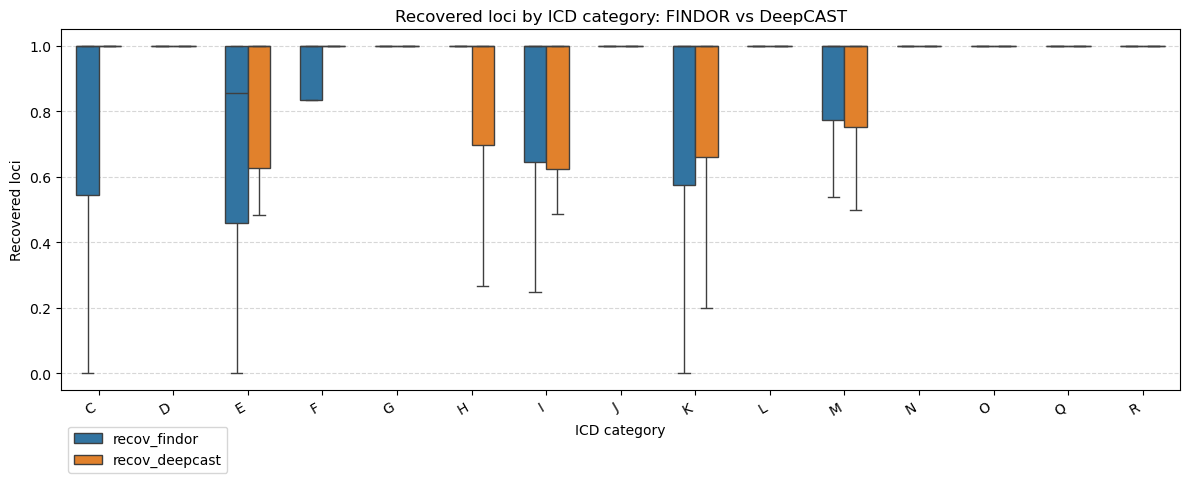

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Long format: one row per (icd_category, method, value)
long = (
    fwer_results[['icd_category', 'recov_findor', 'recov_deepcast']]
    .melt(id_vars='icd_category',
          value_vars=['recov_findor', 'recov_deepcast'],
          var_name='method', value_name='recovered')
    .dropna()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=long, x='icd_category', y='recovered', hue='method',
    dodge=True, width=0.6, showfliers=False  # set showfliers=True if you want outliers
)

# Optional: overlay points for visibility (comment out if not needed)
# sns.stripplot(data=long, x='icd_category', y='recovered', hue='method',
#               dodge=True, alpha=0.35, marker='o', edgecolor='none', ax=ax)

plt.xlabel('ICD category')
plt.ylabel('Recovered loci')
plt.title('Recovered loci by ICD category: FINDOR vs DeepCAST')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='', bbox_to_anchor=(0, -0.25), loc='lower left')
plt.tight_layout()
plt.savefig("plots/fwer_recov_icd_categ.pdf", format="pdf", bbox_inches="tight"); plt.show()

#### Method-specific plots

For each method we want a histogram of the percentage of recovered loci and a bar plot for the newly discovered loci.

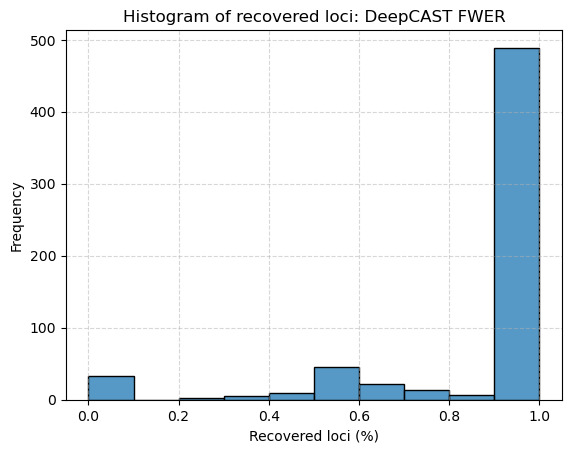

In [29]:
# DeepCAST FWER recovered
sns.histplot(data=fwer_results, x='recov_deepcast', bins=10, edgecolor='black')
plt.xlabel("Recovered loci (%)")
plt.ylabel("Frequency")
plt.title("Histogram of recovered loci: DeepCAST FWER")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/fwer_deepcast_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()

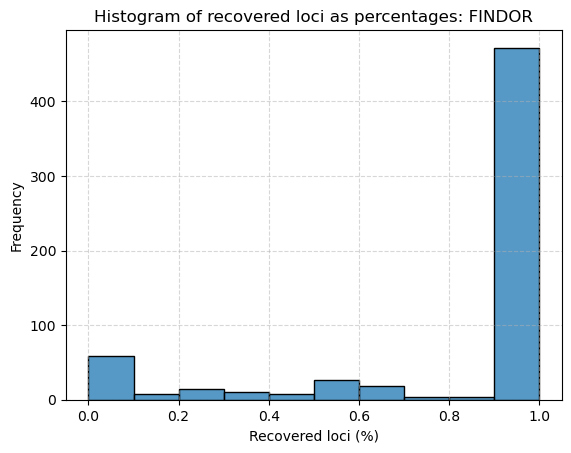

In [30]:
# FINDOR recovered
sns.histplot(data=fwer_results, x='recov_findor', bins=10, edgecolor='black')
plt.xlabel("Recovered loci (%)")
plt.ylabel("Frequency")
plt.title("Histogram of recovered loci as percentages: FINDOR")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/fwer_findor_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()

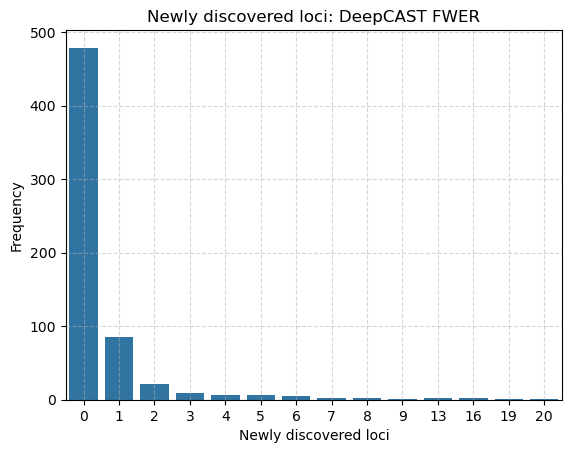

In [32]:
# DeepCAST FWER newly discovered
sns.countplot(data=fwer_results, x='newly_disc_deepcast')
plt.xlabel("Newly discovered loci")
plt.ylabel("Frequency")
plt.title("Newly discovered loci: DeepCAST FWER")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/fwer_deepcast_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

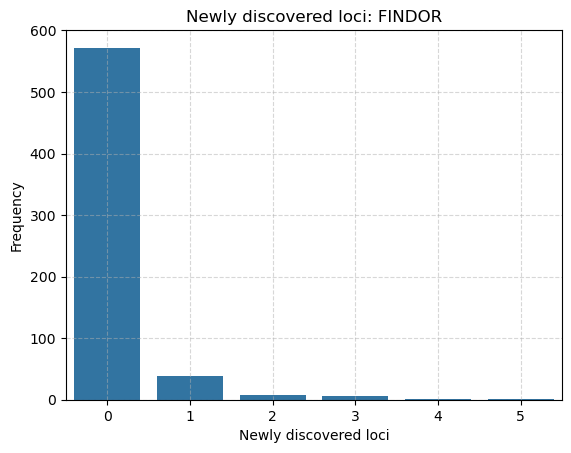

In [33]:
# FINDOR newly discovered
sns.countplot(data=fwer_results, x='newly_disc_findor')
plt.xlabel("Newly discovered loci")
plt.ylabel("Frequency")
plt.title("Newly discovered loci: FINDOR")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/fwer_findor_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

We also want plots with recovered loci on one and discovered loci on the other axis:

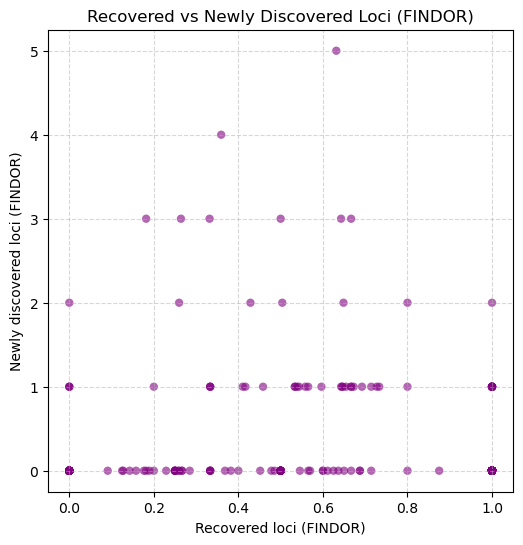

In [34]:
plt.figure(figsize=(6, 6))
sns.scatterplot(
    data=fwer_results,
    x='recov_findor',
    y='newly_disc_findor',
    color='purple',
    alpha=0.6,
    edgecolor='none'
)

plt.xlabel("Recovered loci (FINDOR)")
plt.ylabel("Newly discovered loci (FINDOR)")
plt.title("Recovered vs Newly Discovered Loci (FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [36]:
from scipy.stats import pearsonr, spearmanr

x = fwer_results['recov_findor']
y = fwer_results['newly_disc_findor']

r, p = pearsonr(x, y)
print(f"Pearson correlation: r = {r:.3f}, p-value = {p:.3e}")
rho, p_s = spearmanr(x, y)
print(f"Spearman correlation: ρ = {rho:.3f}, p-value = {p_s:.3e}")

Pearson correlation: r = -0.213, p-value = 7.018e-08
Spearman correlation: ρ = -0.334, p-value = 8.846e-18


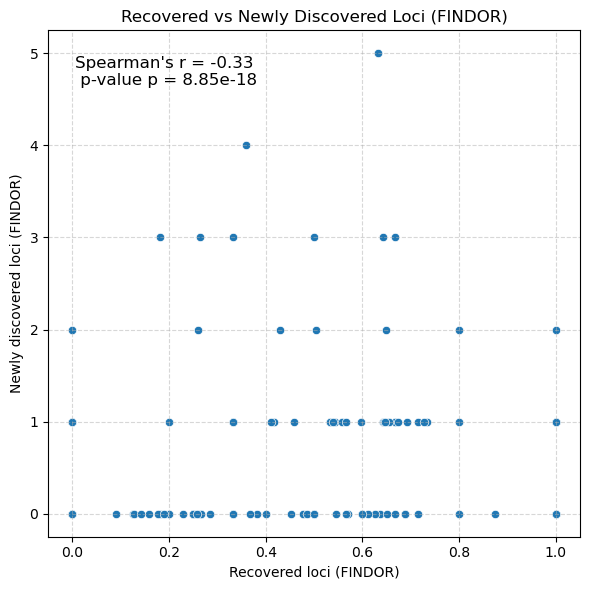

In [37]:
# FINDOR
x = fwer_results['recov_findor']
y = fwer_results['newly_disc_findor']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.scatterplot(
    data=fwer_results,
    x='recov_findor',
    y='newly_disc_findor',
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (FINDOR)")
plt.ylabel("Newly discovered loci (FINDOR)")
plt.title("Recovered vs Newly Discovered Loci (FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_findor_scatter_recovered_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

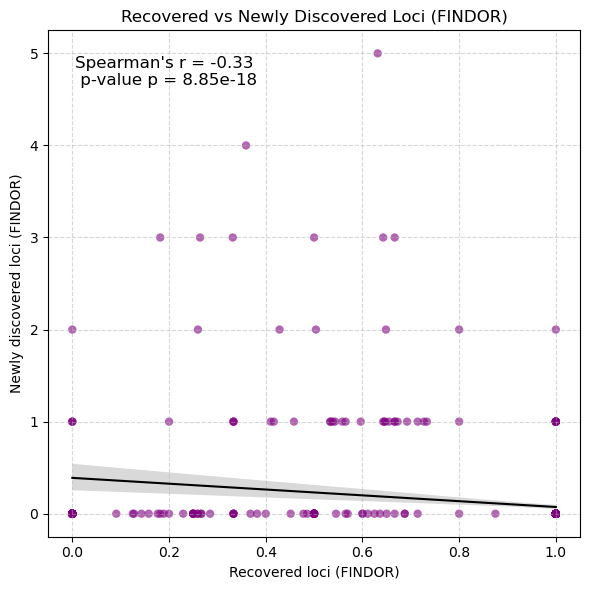

In [38]:
# FINDOR
x = fwer_results['recov_findor']
y = fwer_results['newly_disc_findor']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.regplot(
    data=fwer_results,
    x='recov_findor',
    y='newly_disc_findor',
    scatter_kws={'alpha': 0.6, 'color': 'purple', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95   # set to None to remove confidence interval
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (FINDOR)")
plt.ylabel("Newly discovered loci (FINDOR)")
plt.title("Recovered vs Newly Discovered Loci (FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

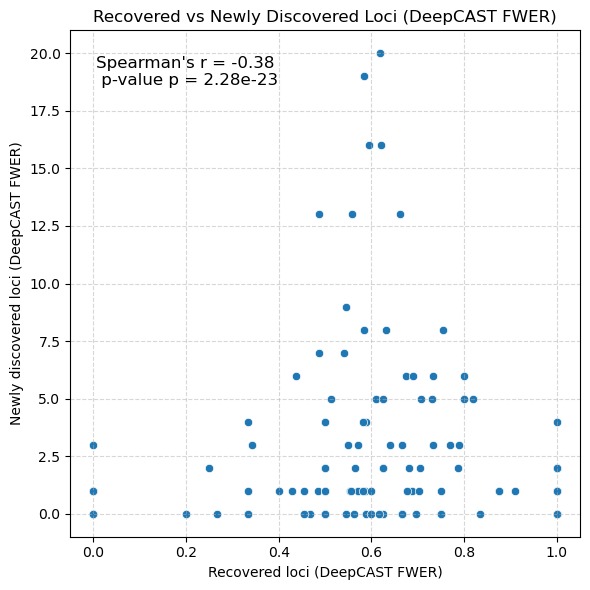

In [39]:
# DeepCAST FWER
x = fwer_results['recov_deepcast']
y = fwer_results['newly_disc_deepcast']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.scatterplot(
    data=fwer_results,
    x='recov_deepcast',
    y='newly_disc_deepcast',
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (DeepCAST FWER)")
plt.ylabel("Newly discovered loci (DeepCAST FWER)")
plt.title("Recovered vs Newly Discovered Loci (DeepCAST FWER)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_deepcast_scatter_recovered_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

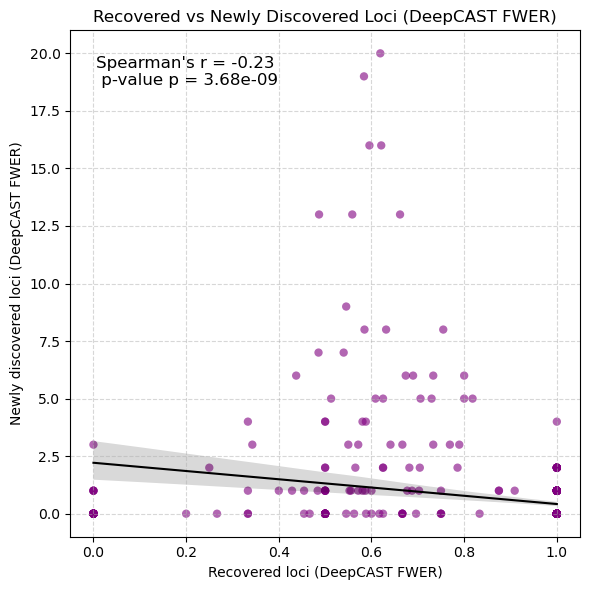

In [ ]:
# DeepCAST FWER
x = fwer_results['recov_deepcast']
y = fwer_results['newly_disc_deepcast']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.regplot(
    data=fwer_results,
    x='recov_deepcast',
    y='newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'purple', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95   # set to None to remove confidence interval
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (DeepCAST FWER)")
plt.ylabel("Newly discovered loci (DeepCAST FWER)")
plt.title("Recovered vs Newly Discovered Loci (DeepCAST FWER)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

We also want to plot the number of discoveries vs the number of cases

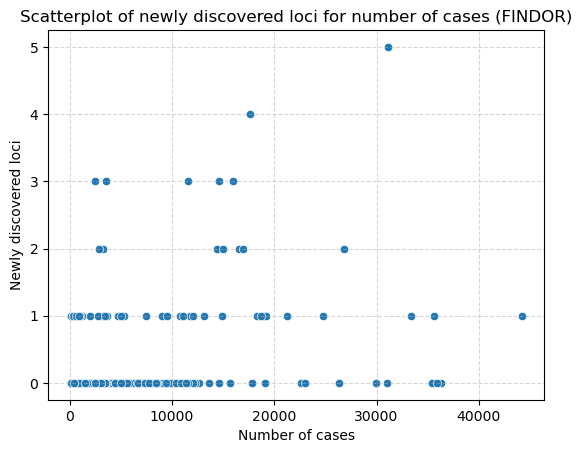

In [40]:
sns.scatterplot(data=fwer_results, x='n_cases', y='newly_disc_findor')

plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci")
plt.title("Scatterplot of newly discovered loci for number of cases (FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

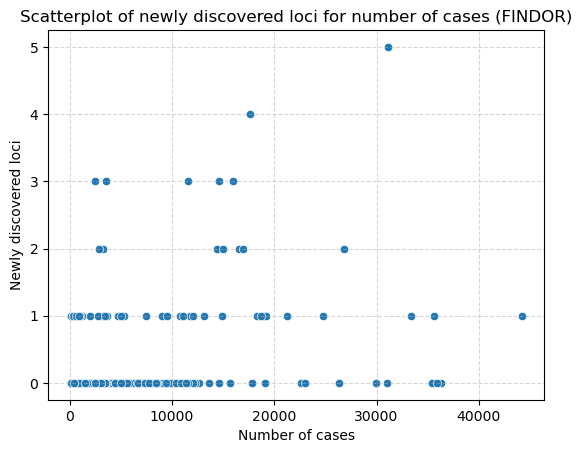

In [ ]:
sns.scatterplot(data=fwer_results, x='n_cases', y='newly_disc_findor')

plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci")
plt.title("Scatterplot of newly discovered loci for number of cases (FINDOR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

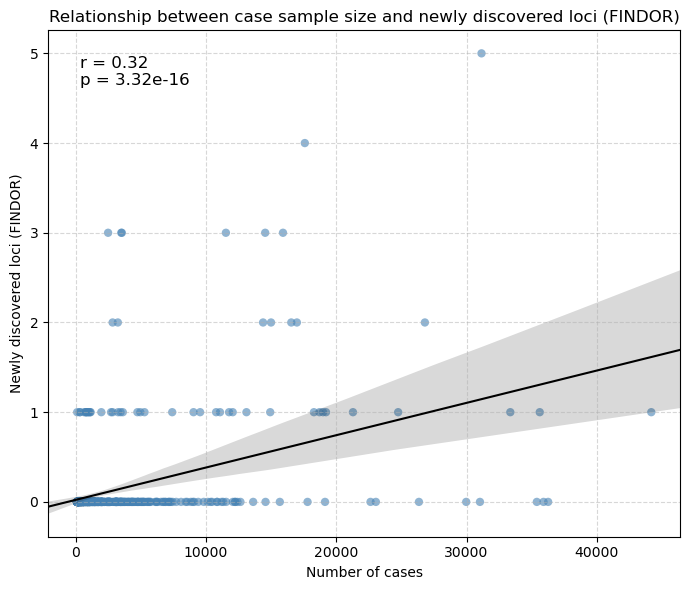

In [47]:
# FINDOR
x = fwer_results['n_cases']
y = fwer_results['newly_disc_findor']
r, p = spearmanr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=fwer_results,
    x='n_cases',
    y='newly_disc_findor',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci (FINDOR)")
plt.title("Relationship between case sample size and newly discovered loci (FINDOR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_findor_n_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

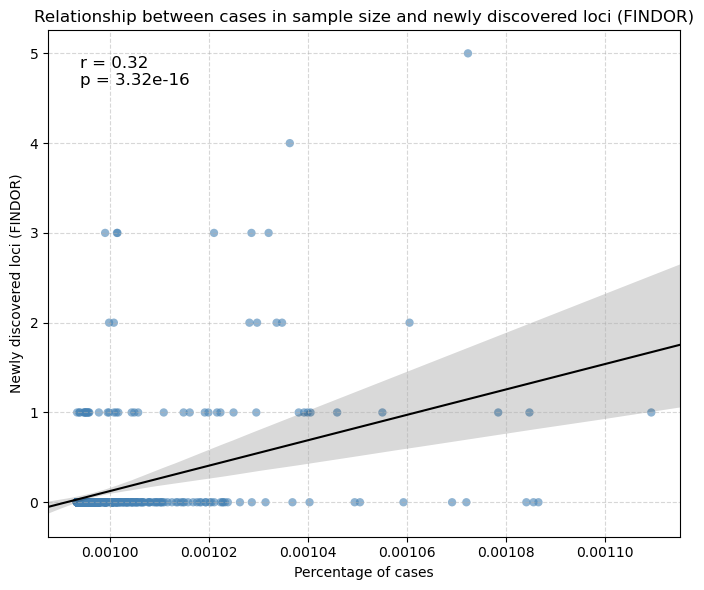

In [46]:
# FINDOR
x = fwer_results['p_cases']
y = fwer_results['newly_disc_findor']
r, p = spearmanr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=fwer_results,
    x='p_cases',
    y='newly_disc_findor',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Percentage of cases")
plt.ylabel("Newly discovered loci (FINDOR)")
plt.title("Relationship between cases in sample size and newly discovered loci (FINDOR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_findor_p_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

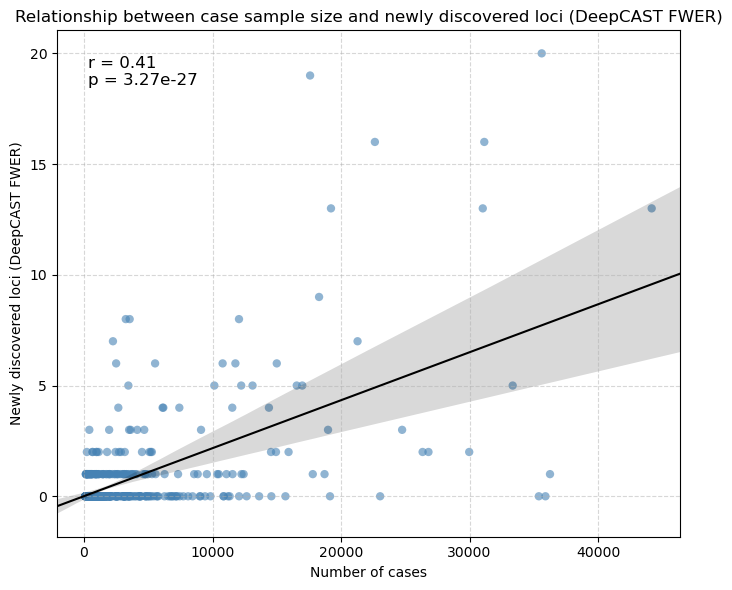

In [45]:
# DeepCAST FWER
x = fwer_results['n_cases']
y = fwer_results['newly_disc_deepcast']
r, p = spearmanr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=fwer_results,
    x='n_cases',
    y='newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci (DeepCAST FWER)")
plt.title("Relationship between case sample size and newly discovered loci (DeepCAST FWER)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_deepcast_n_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

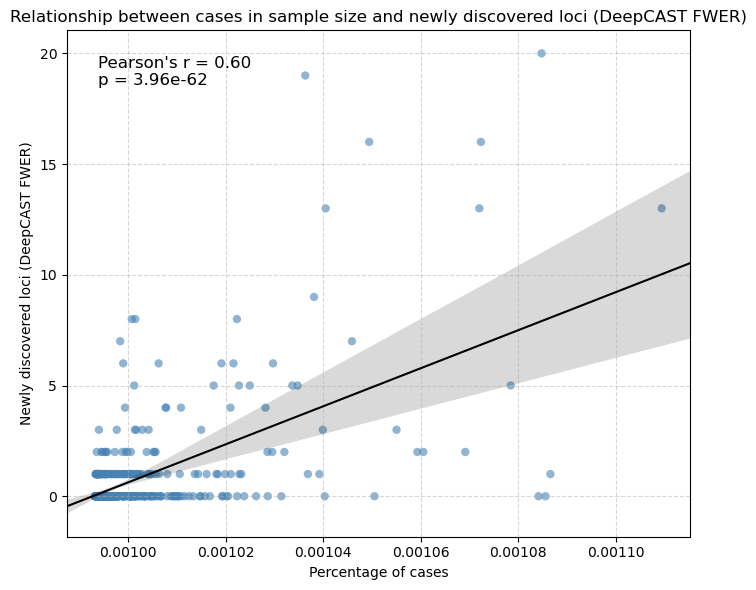

In [44]:
# DeepCAST FWER
x = fwer_results['p_cases']
y = fwer_results['newly_disc_deepcast']
r, p = pearsonr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=fwer_results,
    x='p_cases',
    y='newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Percentage of cases")
plt.ylabel("Newly discovered loci (DeepCAST FWER)")
plt.title("Relationship between cases in sample size and newly discovered loci (DeepCAST FWER)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/fwer_deepcast_p_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

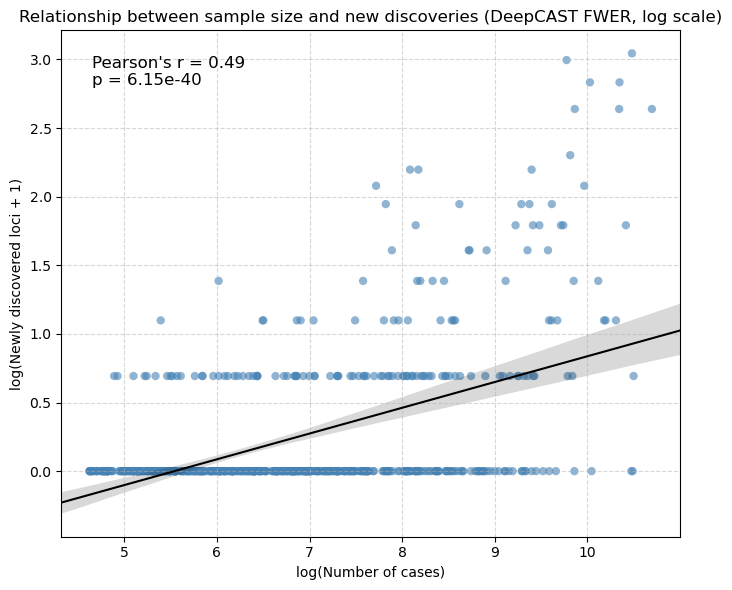

In [43]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Compute transformed variables
x = np.log(fwer_results['n_cases'])
y = np.log1p(fwer_results['newly_disc_deepcast'])

# Correlation on transformed data
r, p = pearsonr(x, y)

# Add transformed columns for plotting (optional)
fwer_results['log_n_cases'] = x
fwer_results['log1p_newly_disc_deepcast'] = y

# Plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=fwer_results,
    x='log_n_cases',
    y='log1p_newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,
    truncate=False
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("log(Number of cases)")
plt.ylabel("log(Newly discovered loci + 1)")
plt.title("Relationship between sample size and new discoveries (DeepCAST FWER, log scale)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig("plots/fwer_deepcast_log_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()


### sFDR plots

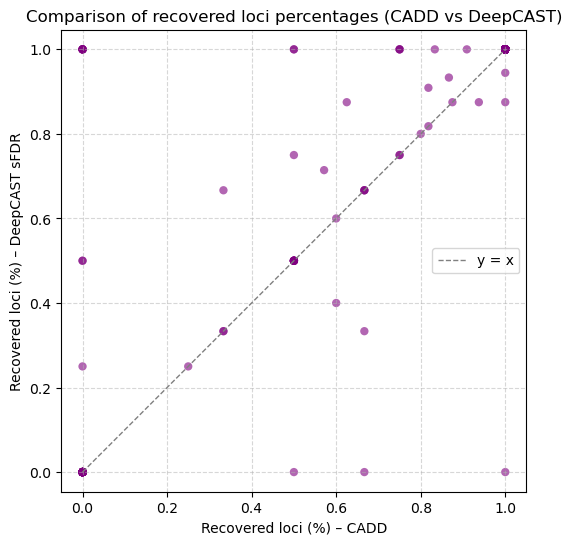

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 6))

# Scatterplot
sns.scatterplot(
    data=sfdr_results,
    x='recov_cadd',
    y='recov_deepcast',
    color='purple',
    alpha=0.6,
    edgecolor='none'
)

# 45° equality line (y = x)
min_val = min(sfdr_results['recov_cadd'].min(), sfdr_results['recov_deepcast'].min())
max_val = max(sfdr_results['recov_cadd'].max(), sfdr_results['recov_deepcast'].max())
plt.plot([min_val, max_val], [min_val, max_val], '--', color='gray', linewidth=1, label='y = x')

plt.xlabel("Recovered loci (%) – CADD")
plt.ylabel("Recovered loci (%) – DeepCAST sFDR")
plt.title("Comparison of recovered loci percentages (CADD vs DeepCAST)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.axis('equal')
plt.savefig("plots/sfdr_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()


In [13]:
sfdr_results[sfdr_results['newly_disc_cadd']>=1000]

,n_cases,p_cases,newly_disc_cadd,newly_disc_deepcast,recov_cadd,recov_deepcast,icd_category,baseline_loci
540,1091.0,0.002594,48887,48131,1.0,1.0,O,48390
547,634.0,0.001508,29629,27671,1.0,1.0,O,163


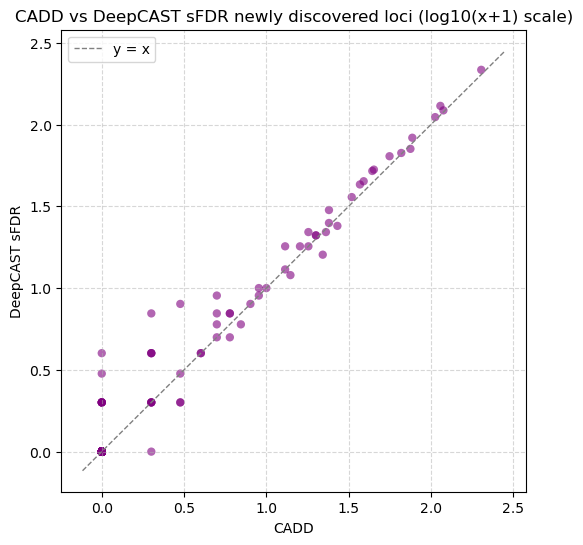

In [ ]:
plt.figure(figsize=(6,6))
# TODO add caption

sns.scatterplot(data=sfdr_results, x=np.log10(sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_cadd']+1),
                          y=np.log10(sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_deepcast']+1),
                          alpha=0.6, color='purple', edgecolor='none')
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, '--', color='gray', linewidth=1, label='y = x')
plt.xlabel("CADD"); plt.ylabel("DeepCAST sFDR")
plt.title("CADD vs DeepCAST sFDR newly discovered loci (log10(x+1) scale)"); plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.savefig("plots/sfdr_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

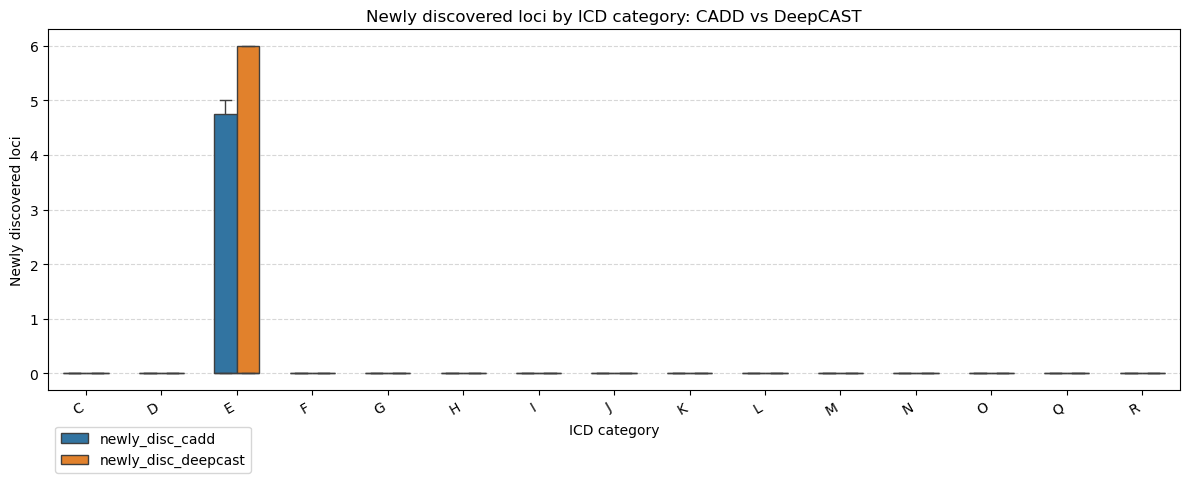

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Long format: one row per (icd_category, method, value)
long = (
    sfdr_results[['icd_category', 'newly_disc_cadd', 'newly_disc_deepcast']]
    .melt(id_vars='icd_category',
          value_vars=['newly_disc_cadd', 'newly_disc_deepcast'],
          var_name='method', value_name='newly_disc')
    .dropna()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=long, x='icd_category', y='newly_disc', hue='method',
    dodge=True, width=0.6, showfliers=False  # set showfliers=True if you want outliers
)

plt.xlabel('ICD category')
plt.ylabel('Newly discovered loci')
plt.title('Newly discovered loci by ICD category: CADD vs DeepCAST')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='', bbox_to_anchor=(0, -0.25), loc='lower left')
plt.tight_layout()
plt.savefig("plots/sfdr_newly_disc_icd_categ.pdf", format="pdf", bbox_inches="tight"); plt.show()

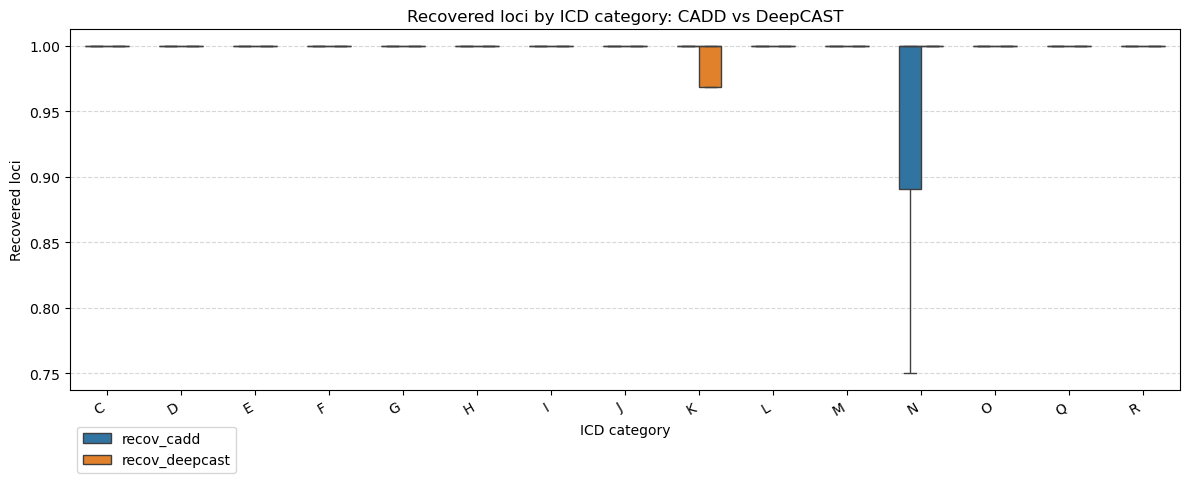

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Long format: one row per (icd_category, method, value)
long = (
    sfdr_results[['icd_category', 'recov_cadd', 'recov_deepcast']]
    .melt(id_vars='icd_category',
          value_vars=['recov_cadd', 'recov_deepcast'],
          var_name='method', value_name='recovered')
    .dropna()
)

plt.figure(figsize=(12, 5))
ax = sns.boxplot(
    data=long, x='icd_category', y='recovered', hue='method',
    dodge=True, width=0.6, showfliers=False  # set showfliers=True if you want outliers
)

# Optional: overlay points for visibility (comment out if not needed)
# sns.stripplot(data=long, x='icd_category', y='recovered', hue='method',
#               dodge=True, alpha=0.35, marker='o', edgecolor='none', ax=ax)

plt.xlabel('ICD category')
plt.ylabel('Recovered loci')
plt.title('Recovered loci by ICD category: CADD vs DeepCAST')
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(title='', bbox_to_anchor=(0, -0.25), loc='lower left')
plt.tight_layout()
plt.savefig("plots/sfdr_recov_icd_categ.pdf", format="pdf", bbox_inches="tight"); plt.show()

#### Method-specific plots

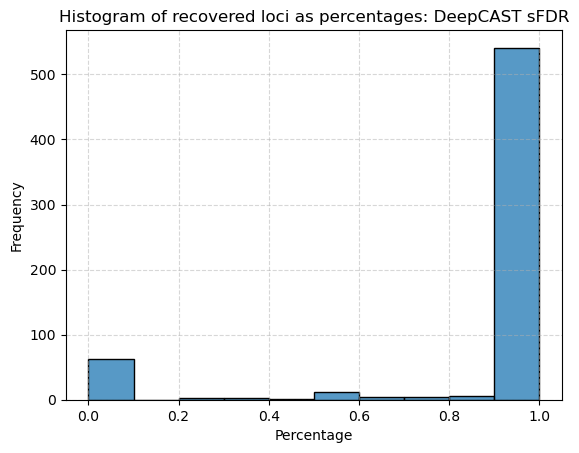

In [53]:
# DeepCAST sFDR recovered
sns.histplot(data=sfdr_results, x='recov_deepcast', bins=10, edgecolor='black')
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.title("Histogram of recovered loci as percentages: DeepCAST sFDR")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/sfdr_deepcast_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()

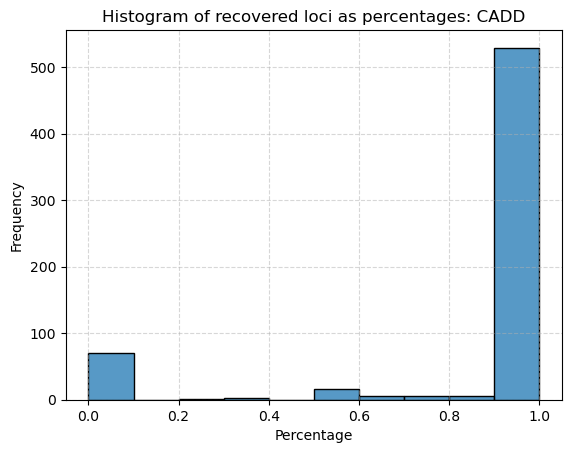

In [54]:
# CADD recovered
sns.histplot(data=sfdr_results, x='recov_cadd', bins=10, edgecolor='black')
plt.xlabel("Percentage")
plt.ylabel("Frequency")
plt.title("Histogram of recovered loci as percentages: CADD")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/sfdr_cadd_recovered.pdf", format="pdf", bbox_inches="tight"); plt.show()

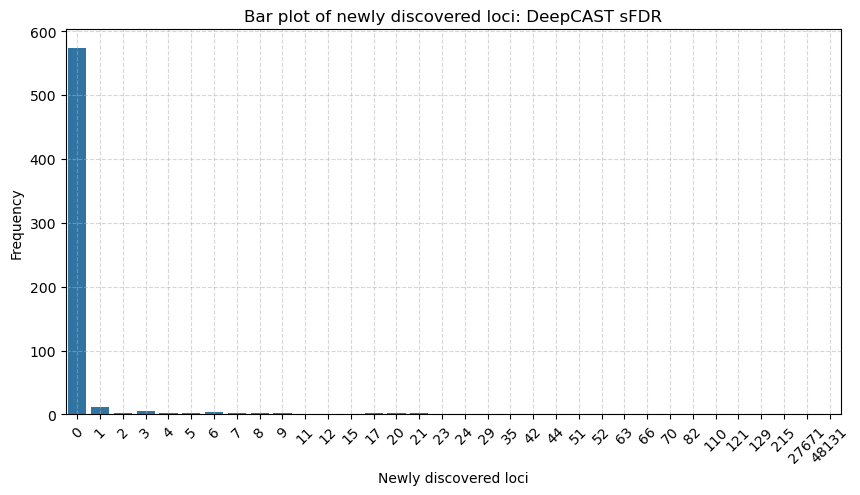

In [66]:
# DeepCAST sFDR newly discovered
plt.figure(figsize=(10, 5))
sns.countplot(data=sfdr_results, x='newly_disc_deepcast')
plt.xticks(rotation=45)
plt.xlabel("Newly discovered loci")
plt.ylabel("Frequency")
plt.title("Bar plot of newly discovered loci: DeepCAST sFDR")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/sfdr_deepcast_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

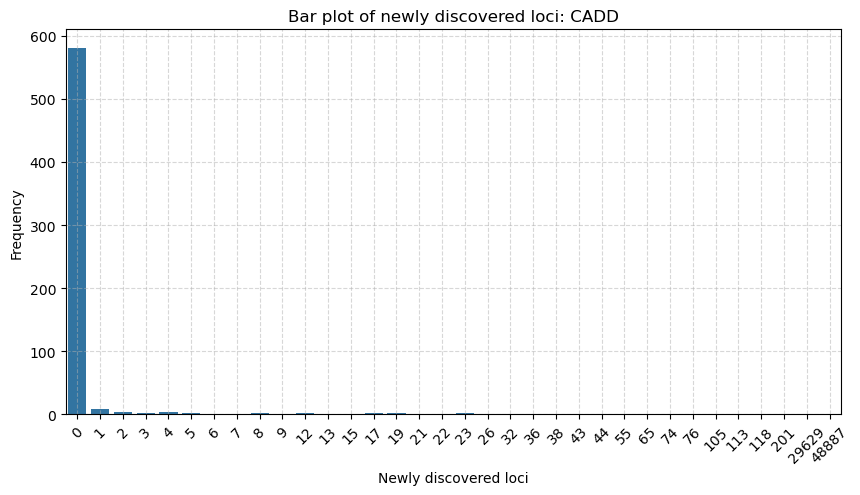

In [67]:
# CADD newly discovered
plt.figure(figsize=(10, 5))
sns.countplot(data=sfdr_results, x='newly_disc_cadd')
plt.xticks(rotation=45)
plt.xlabel("Newly discovered loci")
plt.ylabel("Frequency")
plt.title("Bar plot of newly discovered loci: CADD")
plt.grid(True, linestyle="--", alpha=0.5)
plt.savefig("plots/sfdr_cadd_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

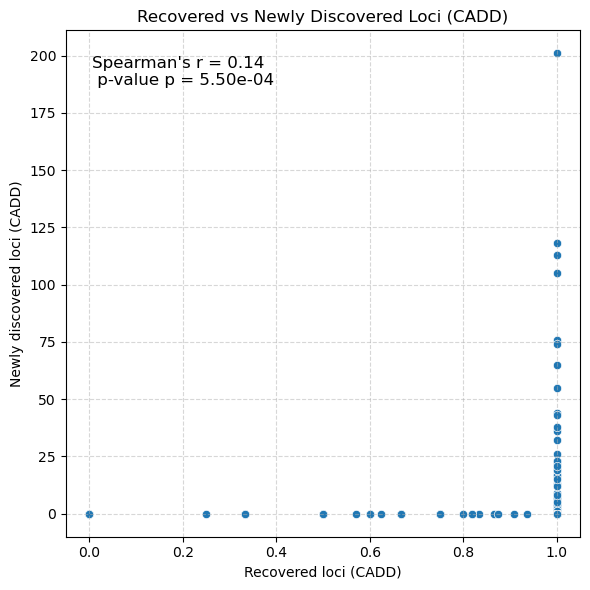

In [ ]:
from scipy.stats import spearmanr
# TODO add caption explaining outliers
# CADD
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['recov_cadd']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_cadd']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.scatterplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='recov_cadd',
    y='newly_disc_cadd',
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (CADD)")
plt.ylabel("Newly discovered loci (CADD)")
plt.title("Recovered vs Newly Discovered Loci (CADD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_cadd_scatter_recovered_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

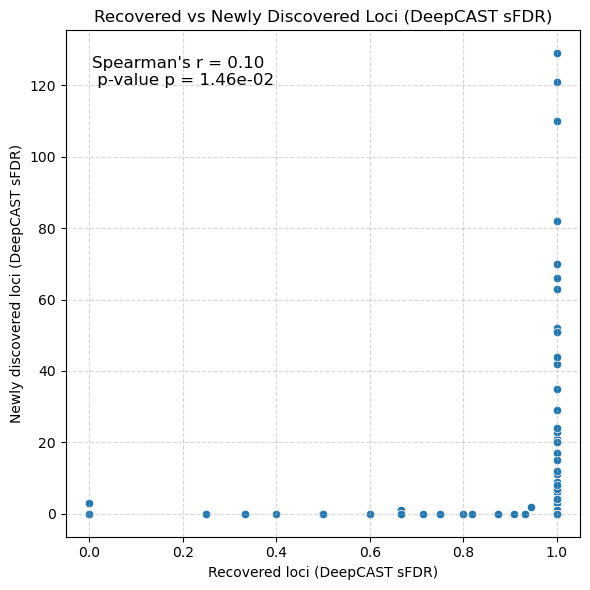

In [ ]:
# DeepCAST sFDR
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['recov_deepcast']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_deepcast']
r, p = spearmanr(x, y)

plt.figure(figsize=(6, 6))

# Scatterplot + regression line
sns.scatterplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='recov_deepcast',
    y='newly_disc_deepcast',
)

# Correlation annotation
plt.text(0.05, 0.95,
         f"Spearman's r = {r:.2f}\n p-value p = {p:.2e}",
         transform=plt.gca().transAxes,
         ha='left', va='top', fontsize=12, color='black')

plt.xlabel("Recovered loci (DeepCAST sFDR)")
plt.ylabel("Newly discovered loci (DeepCAST sFDR)")
plt.title("Recovered vs Newly Discovered Loci (DeepCAST sFDR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_deepcast_scatter_recovered_newly_disc.pdf", format="pdf", bbox_inches="tight"); plt.show()

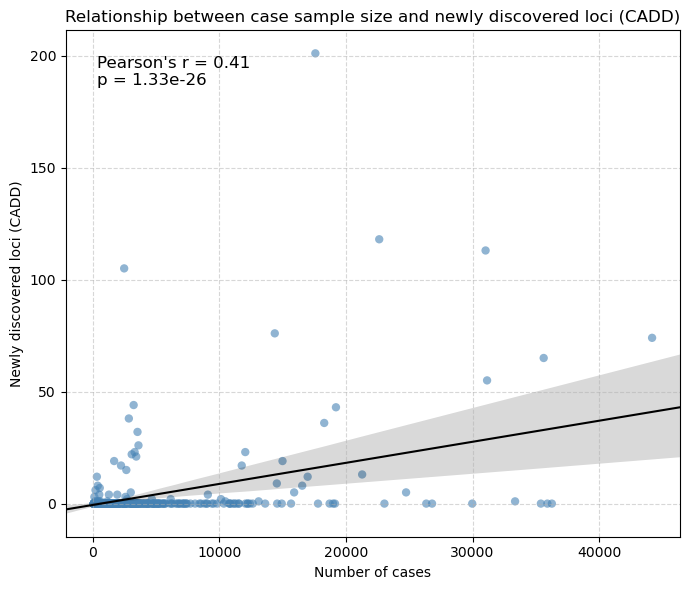

In [23]:
from scipy.stats import pearsonr

# CADD
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['n_cases']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_cadd']
r, p = pearsonr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='n_cases',
    y='newly_disc_cadd',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci (CADD)")
plt.title("Relationship between case sample size and newly discovered loci (CADD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_cadd_n_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

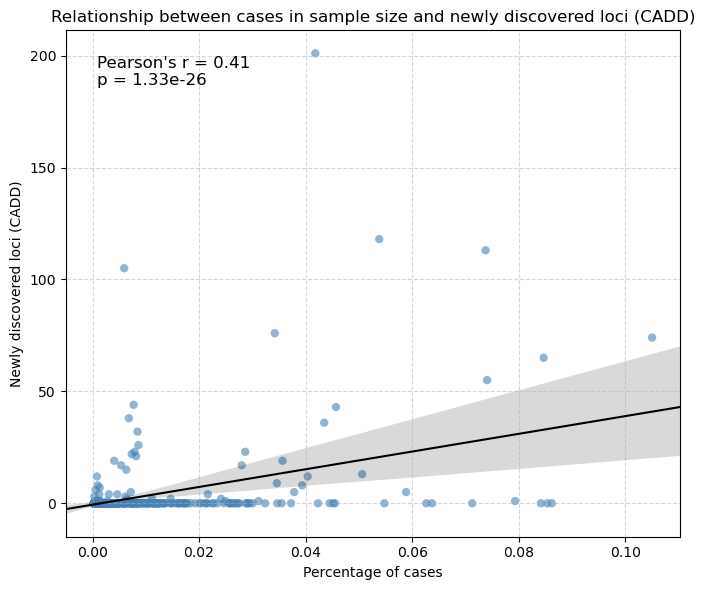

In [24]:
# CADD
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['p_cases']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_cadd']
r, p = pearsonr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='p_cases',
    y='newly_disc_cadd',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Percentage of cases")
plt.ylabel("Newly discovered loci (CADD)")
plt.title("Relationship between cases in sample size and newly discovered loci (CADD)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_cadd_p_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

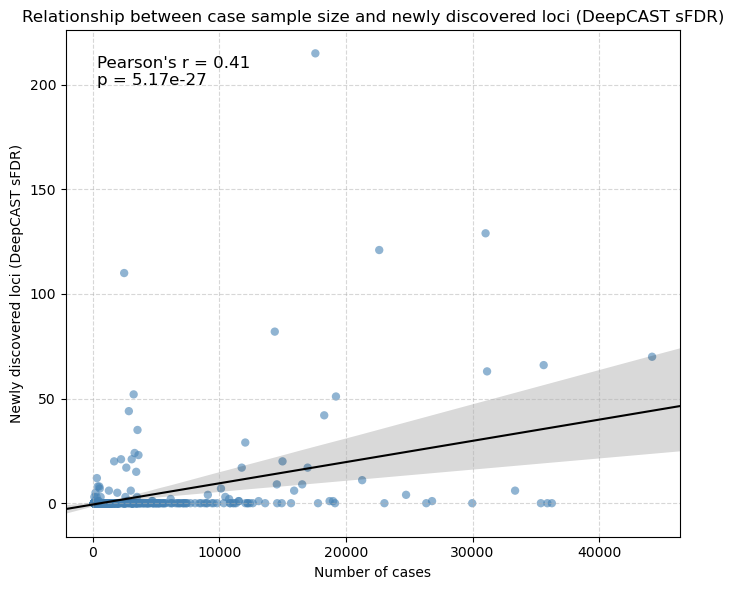

In [25]:
# DeepCAST sFDR
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['n_cases']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_deepcast']
r, p = pearsonr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='n_cases',
    y='newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Number of cases")
plt.ylabel("Newly discovered loci (DeepCAST sFDR)")
plt.title("Relationship between case sample size and newly discovered loci (DeepCAST sFDR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_deepcast_n_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

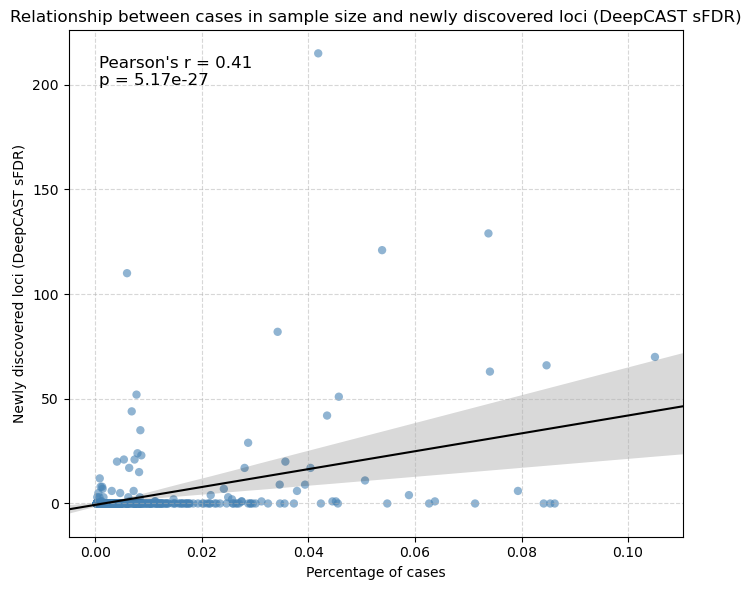

In [26]:
# DeepCAST sFDR
x = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['p_cases']
y = sfdr_results[sfdr_results['newly_disc_cadd']<1000]['newly_disc_deepcast']
r, p = pearsonr(x, y)

# Create the plot
plt.figure(figsize=(7, 6))
ax = sns.regplot(
    data=sfdr_results[sfdr_results['newly_disc_cadd']<1000],
    x='p_cases',
    y='newly_disc_deepcast',
    scatter_kws={'alpha': 0.6, 'color': 'steelblue', 'edgecolor': 'none'},
    line_kws={'color': 'black', 'linewidth': 1.5},
    ci=95,             # 95% confidence interval for regression line
    truncate=False     # keeps the regression line from being cut off
)

# Annotate correlation and p-value
plt.text(0.05, 0.95,
         f"Pearson's r = {r:.2f}\np = {p:.2e}",
         transform=ax.transAxes,
         ha='left', va='top',
         fontsize=12, color='black')

# Labels and styling
plt.xlabel("Percentage of cases")
plt.ylabel("Newly discovered loci (DeepCAST sFDR)")
plt.title("Relationship between cases in sample size and newly discovered loci (DeepCAST sFDR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("plots/sfdr_deepcast_p_cases.pdf", format="pdf", bbox_inches="tight"); plt.show()

## Mechanistic insight:

### Correlation with CADD

In [13]:
import pandas as pd
from config import DEEPCAST_DIR, RESULTS_DIR
from input_output import retrieve_n_controls

correlation_folder_path = RESULTS_DIR / 'correlations' / 'run_7690951'

correlation_scores = []
correlation_pvals = []
mean_sad_score = []

# first_phen = pd.read_csv(correlation_folder_path / "phen4834" / "position_bin_correlations.csv")
# buckets = sorted(first_phen['bucket'].unique(), key=lambda x:int(x.split("_")[0])+int(x.split("_")[1])/1000)

first_phen = pd.read_csv(correlation_folder_path / "phen4834" / "position_bin_correlations.csv").sort_values(
    by='bucket',
    key=lambda s: s.apply(lambda x: int(x.split("_")[0]) + int(x.split("_")[1]) / 1000)
    )
    # key=lambda y:map(y,int(x.split("_")[0])+int(x.split("_")[1])/1000)))
buckets = first_phen['bucket'].unique()

In [14]:
buckets

array(['1_4', '2_234', '3_1', '3_60', '4_5', '5_169', '6_6', '7_24',
       '8_2', '8_3', '8_4', '8_5', '8_6', '8_18', '8_134', '9_1', '9_2',
       '9_4', '9_7', '9_8', '9_117', '10_6', '10_14', '10_29', '10_71',
       '11_5', '11_11', '12_5', '13_95', '14_22', '14_33', '14_95',
       '15_33', '16_6', '16_7', '16_77', '16_78', '16_79', '16_82',
       '16_83', '16_84', '16_86', '20_15', '20_16', '21_41', '21_43',
       '22_26', '22_27', '22_44', '22_48'], dtype=object)

In [ ]:
import pandas as pd
from config import DEEPCAST_DIR, RESULTS_DIR
from input_output import retrieve_n_controls

correlation_folder_path = RESULTS_DIR / 'correlations' / 'run_7690951'

correlation_scores = []
correlation_pvals = []
mean_sad_score = []

first_phen = pd.read_csv(correlation_folder_path / "phen4834" / "position_bin_correlations.csv").sort_values(
    by='bucket',
    key=lambda s: s.apply(lambda x: int(x.split("_")[0]) + int(x.split("_")[1]) / 1000)
    )
buckets = first_phen['bucket'].unique()

result=pd.DataFrame({"bucket":buckets, "pearsonr":[first_phen['']]})

for bucket in buckets:
    for phen_id, folder in zip(phen_ids, result_folders):
        phen_folder = correlation_folder_path / folder
        if phen_folder.exists():
            correlation_file = pd.read_csv(phen_folder / "position_bin_correlations.csv")


            metadata_deepcast = pd.read_csv(deepcast_dir / "metadata.csv")
            n_cases.append(metadata_cadd['MAN_SAD_mean'][0])
            newly_disc_cadd.append(metadata_cadd['num_newly_discovered_loci'][0])
            newly_disc_deepcast.append(metadata_deepcast['num_newly_discovered_loci'][0])
            recov_cadd.append(metadata_cadd['percentage_loci_recovered'][0])
            recov_deepcast.append(metadata_deepcast['percentage_loci_recovered'][0])
            baseline_loci.append(metadata_deepcast['num_loci_baseline'][0])
            icd_category.append(phenotype_identifiers[phen_id])
            p_cases.append(metadata_cadd['n_cases'][0]/(retrieve_n_controls(phen_id)+metadata_cadd['n_cases'][0]))
            
        else:
            print(f'For {folder}: no correlation results were found at {correlation_folder_path}')

sfdr_results = pd.DataFrame({'n_cases':n_cases,
                             'p_cases':p_cases,
                                'newly_disc_cadd':newly_disc_cadd,
                                'newly_disc_deepcast':newly_disc_deepcast,
                                'recov_cadd':recov_cadd,
                                'recov_deepcast':recov_deepcast,
                                'icd_category':icd_category,
                                'baseline_loci':baseline_loci})